# How do you pick a forgetting strategy?

A conjugate linear model never forgets. Each observation adds to the
posterior precision, and after ten thousand rewards the model is as good
as certain. If the world then changes, it takes about as many rewards
again to change its mind. Forgetting is a claim that the parameters move.
The rule you choose is a claim about *how* they move, and this notebook
is about making that claim deliberately.

The rules act on the posterior precision $\Lambda$ (the inverse
covariance) and leave the posterior mean alone, so the figures mostly
track posterior standard deviations. The
[math reference](../math/forgetting.rst) has the equations. Two events
can trigger forgetting in `bayesianbandits`:

- an **update**, through `forgetting=` on the estimator, applied once per
  row before the row is absorbed;
- a **tick** of the clock, through `decay()`, called on your own schedule.

Which rule goes on which event is the whole question.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from scipy import sparse
from scipy.linalg import cho_factor, cho_solve

from bayesianbandits import (
    ExponentialForgetting,
    FeatureWiseForgetting,
    NormalRegressor,
    SiftForgetting,
    StabilizedForgetting,
)

plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

ALPHA = 1.0  # prior precision
BETA = 4.0  # noise precision (noise sd 0.5)


def forget(rule, R, x):
    # The rule returns the forgotten precision (and an effective batch we do not need).
    # Dense rules maintain only the upper triangle, as the estimators do.
    out = rule.update(R, x[None, :], np.zeros(1), alpha=ALPHA)
    R_bar = R if out is None else out[0]
    return np.triu(R_bar) + np.triu(R_bar, 1).T


def absorb(R_bar, theta, x, y):
    # Conjugate update from the forgotten precision.
    R_new = R_bar + BETA * np.outer(x, x)
    theta_new = cho_solve(cho_factor(R_new), R_bar @ theta + BETA * x * y)
    return R_new, theta_new


def covariance(R):
    return cho_solve(cho_factor(R), np.eye(len(R)))

## Why forget

One arm, one coefficient. Its true mean drops from 1.0 to 0.0 halfway
through. Without forgetting the posterior has collapsed by then and the
mean crawls toward the new value at a rate set by how many old
observations it has to outvote. With exponential forgetting at
$\gamma = 0.98$ the posterior width settles at a floor and the mean
tracks the change within a few dozen observations.

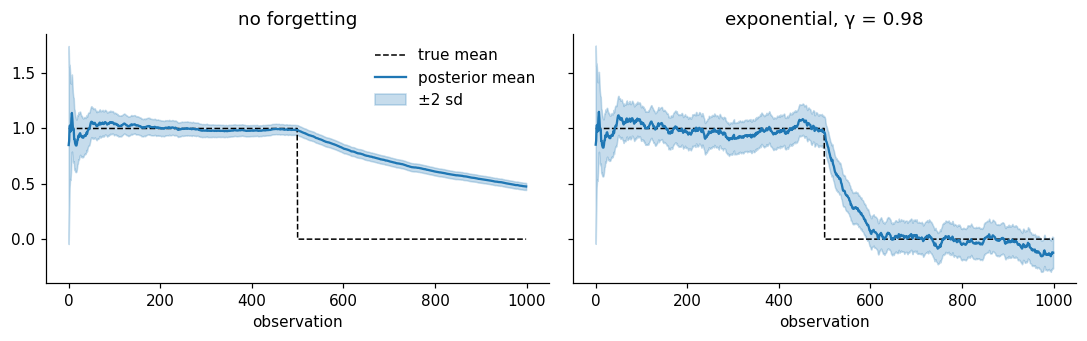

In [2]:
rng = np.random.default_rng(0)
T, SHIFT = 1000, 500
truth = np.where(np.arange(T) < SHIFT, 1.0, 0.0)
rewards = truth + rng.normal(0, 0.5, T)
x1 = np.array([1.0])

fig, axes = plt.subplots(1, 2, figsize=(10, 3.2), sharey=True)
for ax, rule in zip(axes, [None, ExponentialForgetting(0.98)]):
    R, theta = ALPHA * np.eye(1), np.zeros(1)
    means, sds = [], []
    for t in range(T):
        R_bar = R if rule is None else forget(rule, R, x1)
        R, theta = absorb(R_bar, theta, x1, rewards[t])
        means.append(theta[0])
        sds.append(np.sqrt(covariance(R)[0, 0]))
    means, sds = np.array(means), np.array(sds)
    ax.plot(truth, color="k", lw=1, ls="--", label="true mean")
    ax.plot(means, color="C0", label="posterior mean")
    ax.fill_between(
        np.arange(T),
        means - 2 * sds,
        means + 2 * sds,
        color="C0",
        alpha=0.25,
        label="±2 sd",
    )
    ax.set_title("no forgetting" if rule is None else "exponential, γ = 0.98")
    ax.set_xlabel("observation")
axes[0].legend(loc="upper right", frameon=False)
plt.tight_layout()

## Uneven excitation

Exponential forgetting works above because every observation excites the
one coefficient: the precision removed before each row is replaced by
the row. A bandit is not like that. A policy that has settled on an arm
pulls it most of the time and the others rarely, so most rows say nothing
about most directions.

Take the model a shared learner fits: an intercept plus a one-hot column
per arm, so arm $a$ has expected reward $\mu + \tau_a$. Arm 0 gets 90% of
the pulls, arms 1 and 2 get 5% each. Two directions are poorly excited.

1. **The rare arms' cell means.** $\mu + \tau_1$ gains precision one pull
   in twenty and loses a fraction $1 - \gamma$ of it on every one of arm
   0's pulls, which carry no information about it.
2. **The split.** Adding $c$ to $\mu$ and subtracting it from every
   $\tau_a$ changes no cell mean, so no observation ever informs it. Only
   the prior pins it, and the prior decays as $\alpha\gamma^t$.

Precision that is removed and never replaced decays to zero, and the
variance grows without bound. The recursive least squares literature
calls this covariance windup, and it is the reason the directional rules
exist. The run below applies the same 2000 pulls under each rule at
$\gamma = 0.98$ and tracks the posterior sd of arm 1's cell mean and the
variance of the split.

ExponentialForgetting: Cholesky failed at observation 1575


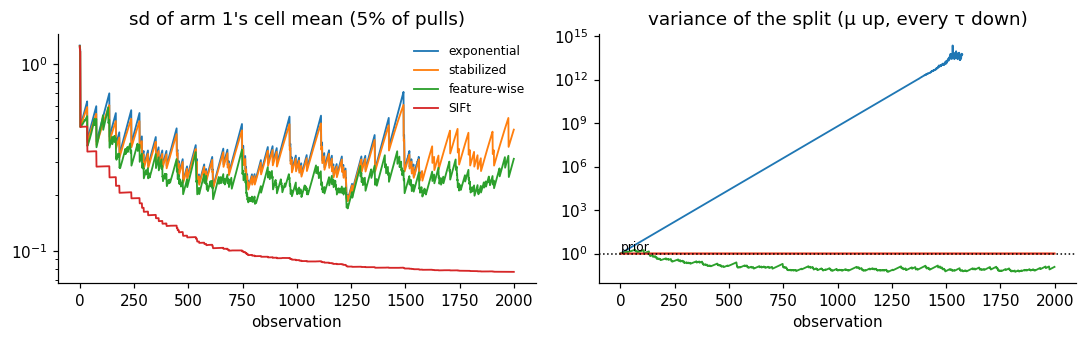

In [3]:
rng = np.random.default_rng(1)
T, GAMMA = 2000, 0.98
P_PULL = np.array([0.9, 0.05, 0.05])
ARM_MEANS = np.array([1.0, 0.5, 0.0])
arms = rng.choice(3, size=T, p=P_PULL)
rewards = ARM_MEANS[arms] + rng.normal(0, 0.5, T)

ROWS = np.hstack([np.ones((3, 1)), np.eye(3)])  # intercept + one-hot
SPLIT = np.array([1.0, -1.0, -1.0, -1.0]) / 2  # mu up, every tau down

RULES = {
    "exponential": ExponentialForgetting(GAMMA),
    "stabilized": StabilizedForgetting(GAMMA),
    "feature-wise": FeatureWiseForgetting(GAMMA),
    "SIFt": SiftForgetting(GAMMA),
}


def run(rule):
    R, theta = ALPHA * np.eye(4), np.zeros(4)
    arm1_sd, split_var = np.full(T, np.nan), np.full(T, np.nan)
    for t in range(T):
        x = ROWS[arms[t]]
        try:
            R, theta = absorb(forget(rule, R, x), theta, x, rewards[t])
        except np.linalg.LinAlgError:
            print(f"{type(rule).__name__}: Cholesky failed at observation {t}")
            break
        S = covariance(R)
        arm1_sd[t] = np.sqrt(ROWS[1] @ S @ ROWS[1])
        split_var[t] = SPLIT @ S @ SPLIT
    return arm1_sd, split_var


results = {name: run(rule) for name, rule in RULES.items()}

fig, axes = plt.subplots(1, 2, figsize=(10, 3.2))
for name, (arm1_sd, split_var) in results.items():
    axes[0].plot(arm1_sd, label=name, lw=1.2)
    axes[1].plot(split_var, label=name, lw=1.2)
axes[0].set_title("sd of arm 1's cell mean (5% of pulls)")
axes[1].set_title("variance of the split (μ up, every τ down)")
axes[1].axhline(1 / ALPHA, color="k", ls=":", lw=1)
axes[1].text(0, 1.4 / ALPHA, "prior", fontsize=8)
for ax in axes:
    ax.set_yscale("log")
    ax.set_xlabel("observation")
axes[0].legend(frameon=False, fontsize=8)
plt.tight_layout()

Exponential forgetting winds up in both directions. Arm 1 widens on pulls
that say nothing about it, and the variance of the split grows by
fourteen orders of magnitude until the Cholesky factorization fails.

Stabilized forgetting (Kulhavý and Zarrop 1993) adds $(1 - \gamma)\alpha$
back onto the diagonal after scaling, so no direction decays past the
prior. That bounds the windup without removing its cause: arm 1 is still
forgotten on arm 0's pulls, right down to the prior floor.

## Forget only what new data replaces

Kulhavý and Kárný (1984) put the fix as a principle: forget only the
information that the new data replaces. A pull of arm 0 informs one
direction, arm 0's cell mean, so that is the only direction that should
pay for it. Two rules do this.

- **SIFt** (Lai and Bernstein 2024) subtracts a rank-one term along
  $\Lambda x$, which is exactly the direction the row refills.
- **Feature-wise** forgetting (Saelid and Foss 1983, Vahidi et al. 2005)
  scales the coordinates that appear in the row and leaves the others.

Neither winds up. They differ on the shared intercept column: feature-wise
forgets $\mu$ coordinate by coordinate on every pull, which loosens the
rare arms' cell means more than SIFt does and moves the split away from
the prior. The math reference works through why. The difference that
usually decides between them is sparsity.

### SIFt fills in

A sparse model's precision has a nonzero wherever two features have
appeared in the same row: with an intercept, arm columns and arm-by-segment
cells the pattern is a star, and it stays a star however many rows arrive.
Exponential, stabilized and feature-wise forgetting scale entries in
place. SIFt subtracts $\Lambda x x^\top \Lambda$, and $\Lambda x$ is
nonzero on every feature that has ever shared a row with the observed
ones. With a shared intercept that is every feature seen so far.

exponential   nnz after 400 observations:    1767  (0.6% dense)
feature-wise  nnz after 400 observations:    1767  (0.6% dense)
SIFt          nnz after 400 observations:  109121  (35.9% dense)


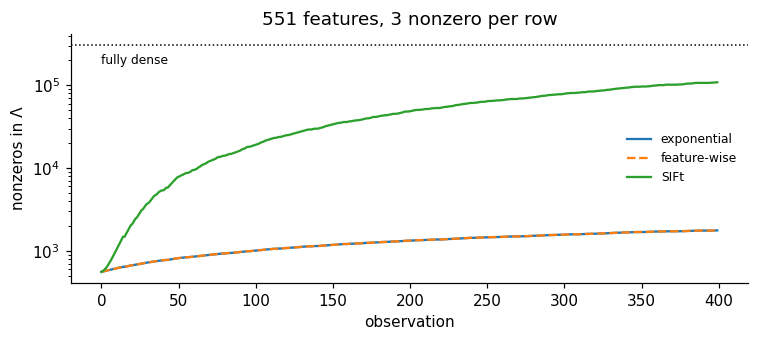

In [4]:
N_ARMS, N_SEG = 50, 10
P = 1 + N_ARMS + N_ARMS * N_SEG
rng = np.random.default_rng(2)


def sparse_row(arm, seg):
    cols = [0, 1 + arm, 1 + N_ARMS + arm * N_SEG + seg]
    return sparse.csc_array((np.ones(3), ([0, 0, 0], cols)), shape=(1, P))


T_SPARSE = 400
draws = [(rng.integers(N_ARMS), rng.integers(N_SEG)) for _ in range(T_SPARSE)]
nnz = {}
for name in ["exponential", "feature-wise", "SIFt"]:
    R = sparse.csc_array(ALPHA * sparse.eye(P))
    counts = []
    for arm, seg in draws:
        X = sparse_row(arm, seg)
        R_bar, _, _ = RULES[name].update(R, X, np.zeros(1), alpha=ALPHA)
        R = sparse.csc_array(R_bar + BETA * (X.T @ X))
        R.eliminate_zeros()
        counts.append(R.nnz)
    nnz[name] = np.array(counts)

fig, ax = plt.subplots(figsize=(7, 3.2))
for name, counts in nnz.items():
    ax.plot(counts, label=name, lw=1.5, ls="--" if name == "feature-wise" else "-")
ax.axhline(P * P, color="k", ls=":", lw=1)
ax.text(0, P * P * 0.8, "fully dense", fontsize=8, va="top")
ax.set_yscale("log")
ax.set_xlabel("observation")
ax.set_ylabel("nonzeros in Λ")
ax.set_title(f"{P} features, 3 nonzero per row")
ax.legend(frameon=False, fontsize=8)
plt.tight_layout()
for name, counts in nnz.items():
    print(
        f"{name:13s} nnz after {T_SPARSE} observations: {counts[-1]:>7d}  ({counts[-1] / P**2:.1%} dense)"
    )

At a million features, which is where the sparse estimators are meant to
run, that is not a slowdown but a memory failure. SIFt is a dense-model
rule; feature-wise is the directional rule for sparse models, and the
sparse estimators refuse SIFt.

## Untouched is also a claim

A directional rule leaves an unpulled arm exactly as it was. That is
correct if the arm's reward changes only when you observe it, and wrong
if it changes with time. An arm the policy stopped pulling keeps a stale
posterior, and nothing on the update event will ever widen it.

The remedy is the second event. A tick of the clock should widen every
direction, because time passed for every direction, and it should widen
toward the prior rather than toward nothing, or the unpulled arms wind up
as in the first figure. That is `decay()` with a stabilized rule, called
once per unit of time.

The simulation below runs Thompson sampling on the same three-arm model
with the estimator's public API. Arm 2 starts as the worst arm and
becomes the best at round 1000. Four learners: no forgetting, feature-wise
on the update event, a stabilized tick every 25 rounds, and both.

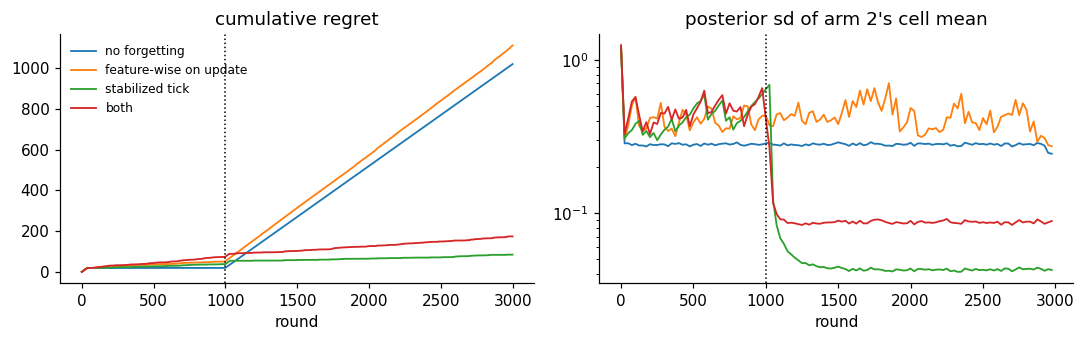

In [5]:
T, CHANGE, EVERY = 3000, 1000, 25
TRUE = np.where(np.arange(T)[:, None] < CHANGE, [1.0, 0.5, 0.0], [1.0, 0.5, 1.5])


def thompson(forgetting=None, tick=None, seed=3):
    rng = np.random.default_rng(seed)
    model = NormalRegressor(
        alpha=ALPHA, beta=BETA, forgetting=forgetting, random_state=seed
    )
    regret, arm2_sd = np.zeros(T), np.full(T, np.nan)
    for t in range(T):
        a = int(np.argmax(model.sample(ROWS)))
        model.partial_fit(ROWS[a : a + 1], np.array([TRUE[t, a] + rng.normal(0, 0.5)]))
        regret[t] = TRUE[t].max() - TRUE[t, a]
        if tick is not None and (t + 1) % EVERY == 0:
            model.decay(tick)
        if t % EVERY == 0:
            arm2_sd[t] = model.sample(ROWS[2:3], size=2000).std()
    return np.cumsum(regret), arm2_sd


learners = {
    "no forgetting": thompson(),
    "feature-wise on update": thompson(forgetting=FeatureWiseForgetting(0.98)),
    "stabilized tick": thompson(tick=StabilizedForgetting(0.85)),
    "both": thompson(
        forgetting=FeatureWiseForgetting(0.98), tick=StabilizedForgetting(0.85)
    ),
}

fig, axes = plt.subplots(1, 2, figsize=(10, 3.2))
for name, (regret, arm2_sd) in learners.items():
    axes[0].plot(regret, label=name, lw=1.2)
    ok = ~np.isnan(arm2_sd)
    axes[1].plot(np.flatnonzero(ok), arm2_sd[ok], label=name, lw=1.2)
for ax in axes:
    ax.axvline(CHANGE, color="k", ls=":", lw=1)
    ax.set_xlabel("round")
axes[0].set_title("cumulative regret")
axes[1].set_title("posterior sd of arm 2's cell mean")
axes[1].set_yscale("log")
axes[0].legend(frameon=False, fontsize=8)
plt.tight_layout()

No forgetting and feature-wise on the update event never find the
change. Arm 2 was pulled a handful of times early, its posterior settled
on "a bad arm", and nothing widens a posterior that is not being sampled.
Feature-wise forgets arm 2 only on arm 2's own pulls, and those have
stopped. The stabilized tick widens every arm toward the prior between
pulls, Thompson sampling revisits arm 2 within a few hundred rounds of
the change, and the regret curve flattens. Adding feature-wise to the
tick changes little here, because nothing in this simulation changes when
an arm is observed. The tick is what the calendar needs; the update rule
is for change that arrives with the observation.

## The precedent: TrueSkill 2

Skill rating systems faced the same choice and settled it from data.
Original TrueSkill (Herbrich et al. 2007) let a player's skill change only
by playing: after each match, skill gets Gaussian noise with variance
$\gamma^2$. Glickman (1999) made the opposite assumption, a variance
$\tau^2$ per unit of calendar time, whether or not the player plays.
TrueSkill 2 (Minka et al. 2018) keeps both, on the grounds that "a player
gains experience from each match they play, and their sharpness decreases
over time without play." Its online algorithm widens a player's variance
by the elapsed time since their last match, then processes the match,
which adds the per-match noise.

In the terms of this notebook, the per-match noise is feature-wise
forgetting on the update event: only the players in the match are
widened. The per-time noise is the tick. The fitted Halo 5 rates put the
per-match term far ahead, with about 100,000 minutes of not playing
worth one match, and the systematic gain from experience is handled as a
mean shift rather than as forgetting, because its sign is known. Two
things carry over.

- If the hidden state moves on both the sampling event and the calendar,
  use both events, and expect to fit the two rates separately.
- If you know which way the state moves, model the shift; forgetting is
  for change whose direction you will not commit to.

TrueSkill's time term has no floor, so an absent player's variance grows
without bound. That is the windup from the second figure, and the
stabilized tick is what this library does about it.

## Both events in one agent

The two claims are two lines. The rule on the estimator forgets on every
update; the rule passed to `decay()` forgets when you say the clock
ticked, and `steps=` raises its rate to a power if the job missed a few.

In [6]:
from bayesianbandits import Arm, ContextualAgent, ThompsonSampling

arms = [
    Arm(
        a,
        learner=NormalRegressor(
            alpha=1.0, beta=4.0, forgetting=FeatureWiseForgetting(0.98)
        ),
    )
    for a in range(3)
]
agent = ContextualAgent(arms, ThompsonSampling(), random_seed=0)

X = np.ones((1, 1))
(action,) = agent.pull(X)
agent.update(X, np.array([1.0]))  # forgets along this row, then absorbs it

agent.decay(StabilizedForgetting(0.9), steps=2)  # two days passed
print(action, agent.arms[0].learner.forgetting)

2 FeatureWiseForgetting(rate=0.98)


## Choosing

Start from what you believe moves. The same $\gamma$ means different
amounts of forgetting under different rules, since exponential removes
$1 - \gamma$ of the precision in every direction and feature-wise only in
the observed coordinates, so retune when you switch.

| What moves | On the estimator | On the clock |
|---|---|---|
| Nothing you believe in | `forgetting=None` (default) | no `decay()` |
| Rewards drift with time | none | `decay(StabilizedForgetting(γ))` once per period |
| Rewards change when observed, dense model | `forgetting=SiftForgetting(γ)` | none |
| Rewards change when observed, sparse model | `forgetting=FeatureWiseForgetting(γ)` | none |
| Both | a directional rule | a stabilized tick |
| Empirical Bayes estimators | uniform rules only; the floor is the tuned `alpha` | `decay()` is stabilized by default |

Plain `ExponentialForgetting` remains the default tick on the
non-empirical-Bayes estimators for compatibility. It is the right rule
only when every direction is excited between ticks; otherwise it is the
first figure of this notebook.

## References

- Kulhavý, R. and Kárný, M. (1984). Tracking of slowly varying parameters
  by directional forgetting. *IFAC World Congress*.
- Kulhavý, R. and Zarrop, M. B. (1993). On a general concept of
  forgetting. *International Journal of Control* 58(4).
- Saelid, S. and Foss, B. (1983). Adaptive controllers with a vector
  variable forgetting factor. *IEEE CDC*.
- Vahidi, A., Stefanopoulou, A. and Peng, H. (2005). Recursive least
  squares with forgetting for online estimation of vehicle mass and road
  grade. *Vehicle System Dynamics* 43(1).
- Lai, B. and Bernstein, D. S. (2024). SIFt-RLS: Subspace of information
  forgetting recursive least squares. *arXiv:2404.10844*.
- Herbrich, R., Minka, T. and Graepel, T. (2007). TrueSkill: a Bayesian
  skill rating system. *NeurIPS*.
- Minka, T., Cleven, R. and Zaykov, Y. (2018). TrueSkill 2: an improved
  Bayesian skill rating system. *Microsoft Research technical report*.